# 0 : Setup

In [ ]:
import sys, json, random, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
warnings.filterwarnings("ignore")


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device : {device}")
if(device=="cuda"):
    print(f"    GPU : {torch.cuda.get_device_name()}")
    print(f"    VRAM: {torch.cuda.get_device_properties().total_memory} GB")

from google.colab import drive
drive.mount('/content/drive')


# paths
DRIVE_ROOT  = Path('/content/drive/MyDrive/CropClassifier_v2')
DATA_ROOT   = Path('/content/dataset/resized_256')
MINI_DIR    = Path('/content/mini')
MINI_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DIR   = DRIVE_ROOT / 'models' / 'stage1_crop'
SAVE_MINI   = MODEL_DIR / 'efficientnet_b1_crop_mini.pt'

MINI_TRAIN  = MINI_DIR / 'train_mini.csv'
MINI_VAL    = MINI_DIR / 'val_mini.csv'
MINI_TEST   = MINI_DIR / 'test_mini.csv'


# hyperparameters
MODEL_NAME = 'efficientnet_b1'
NUM_CLASSES = 32
TRAIN_PER_CLASS = 70
VAL_PER_CLASS = 15
TEST_PER_CLASS = 15

IMG_SIZE = 240

NORM_MEAN = (0.5, 0.5, 0.5)
NORM_STD = (0.5, 0.5, 0.5)

BATCH_SIZE = 64
NUM_WORKERS = 4
DROPOUT = 0.3
LABEL_SMOOTHING  = 0.1

EPOCHS = 8
LR = 1e-3
WEIGHT_DECAY = 1e-4

print(f"setup complete ")
print(f'    {TRAIN_PER_CLASS*NUM_CLASSES} train | {VAL_PER_CLASS*NUM_CLASSES} val | {TEST_PER_CLASS*NUM_CLASSES} test  (approx)')


device : cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
setup complete 
    2240 train | 480 val | 480 test  (approx)


# 01 : Sub-Sampling Manifests

In [ ]:
!cat /content/drive/MyDrive/disease_detection/resized_part_* > /content/resized_256.zip
!unzip -q -o /content/resized_256.zip -d /content/dataset -x "__MACOSX/*" "*/._*"

import zipfile
from pathlib import Path

MERGED_DIR = Path('/content/dataset/resized_256/soybean')
MERGED_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile('/content/drive/MyDrive/CropClassifier_v2/soybean_merged_backup.zip', 'r') as zf:
    zf.extractall(MERGED_DIR)

print(f'✅  Dataset ready')
print(f'    soybean/ : {len(list(MERGED_DIR.iterdir())):,} files')

✅  Dataset ready
    soybean/ : 2,815 files


In [ ]:
import pandas as pd

if not DATA_ROOT.exists():
    print('->RAW IMAGES MISSING — re-extract from Drive zip before training')
    print('    Then re-run this cell.')
else:
    n_folders = (1 for f in DATA_ROOT.iterdir() if f.is_dir())
    print(f'->Raw images present: {n_folders} crop folders')


# Load class map
with open(MODEL_DIR / 'class_to_idx.json') as f:
    class_to_idx = json.load(f)
idx_to_class = {v : k for k, v in class_to_idx.items()}

assert len(class_to_idx) == NUM_CLASSES, f'class_to_idx has {len(class_to_idx)} classes, expected {NUM_CLASSES}'


def subsample(csv_path, n_per_class, seed=SEED):
    df = pd.read_csv(csv_path)
    return (df.groupby(
        'crop', group_keys=False
    ).apply(lambda g: g.sample(min(len(g), n_per_class), random_state=SEED)
    ).reset_index(drop=True)
    )

train_df = subsample(DRIVE_ROOT / 'train_manifest.csv', TRAIN_PER_CLASS)
val_df   = subsample(DRIVE_ROOT / 'val_manifest.csv',   VAL_PER_CLASS)
test_df  = subsample(DRIVE_ROOT / 'test_manifest.csv',  TEST_PER_CLASS)

train_df.to_csv(MINI_TRAIN, index=False)
val_df.to_csv(MINI_VAL,     index=False)
test_df.to_csv(MINI_TEST,   index=False)


print(f'\n✅  Mini manifests saved to {MINI_DIR}')
print(f'    Train : {len(train_df):,}  ({train_df["crop"].nunique()} classes)')
print(f'    Val   : {len(val_df):,}  ({val_df["crop"].nunique()} classes)')
print(f'    Test  : {len(test_df):,}  ({test_df["crop"].nunique()} classes)')

print(f'\nPer-class train counts:')
counts = train_df['crop'].value_counts().sort_index()
missing_cls = set(class_to_idx) - set(counts.index)
if missing_cls:
    print(f'  🔴 Zero training samples: {missing_cls}')
for cls, n in counts.items():
    flag = f'  ⚠️  only {n} available' if n < TRAIN_PER_CLASS else ''
    print(f'  {cls:<18} {n:>3}{flag}')

->Raw images present: <generator object <genexpr> at 0x7b4e8d87f9f0> crop folders

✅  Mini manifests saved to /content/mini
    Train : 2,240  (32 classes)
    Val   : 480  (32 classes)
    Test  : 480  (32 classes)

Per-class train counts:
  apple               70
  bean                70
  bell_pepper         70
  blackgram           70
  blueberry           70
  cherry              70
  chilli              70
  coconut             70
  coffee              70
  corn                70
  cotton              70
  dragon_fruit        70
  grape               70
  groundnut           70
  jute                70
  lemon               70
  mango               70
  onion               70
  orange              70
  paddy               70
  peach               70
  pineapple           70
  potato              70
  raspberry           70
  snake_gourd         70
  soybean             70
  squash              70
  strawberry          70
  sugarcane           70
  tea                 70
  tomato 

In [ ]:
import pandas as pd
from pathlib import Path

DATA_ROOT = Path('/content/dataset/resized_256')
MINI_DIR  = Path('/content/mini')
IMG_EXTS  = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

# Get actual filenames on disk for soybean
actual_files = [
    f'soybean/{f.name}'
    for f in (DATA_ROOT / 'soybean').iterdir()
    if f.suffix.lower() in IMG_EXTS
]
print(f'Actual soybean files on disk: {len(actual_files)}')

# For each mini split, replace the broken soybean rows with real paths
for split_name, csv_path in [('train', MINI_DIR/'train_mini.csv'),
                               ('val',   MINI_DIR/'val_mini.csv'),
                               ('test',  MINI_DIR/'test_mini.csv')]:
    df = pd.read_csv(csv_path)
    n_soy = (df['crop'] == 'soybean').sum()

    # Sample n_soy files from actual disk files (no overlap across splits ideally,
    # but at this mini scale it doesn't matter much)
    sampled = pd.DataFrame({
        'filepath': actual_files[:n_soy],
        'crop': 'soybean',
    })
    # drop broken soybean rows, append real ones
    df = pd.concat([df[df['crop'] != 'soybean'], sampled], ignore_index=True)
    df.to_csv(csv_path, index=False)
    print(f'  {split_name}: replaced {n_soy} soybean rows')

print('\n✅  Done — re-run Cell 03')

Actual soybean files on disk: 2815
  train: replaced 70 soybean rows
  val: replaced 15 soybean rows
  test: replaced 15 soybean rows

✅  Done — re-run Cell 03


In [ ]:
import random, shutil

SEED = 42
random.seed(SEED)
random.shuffle(actual_files)

n_train = int(len(actual_files) * 0.70)
n_val   = int(len(actual_files) * 0.15)

splits = {
    'train': actual_files[:n_train],
    'val'  : actual_files[n_train:n_train+n_val],
    'test' : actual_files[n_train+n_val:],
}

DRIVE_ROOT = Path('/content/drive/MyDrive/CropClassifier_v2')
for split_name, files in splits.items():
    csv_path = DRIVE_ROOT / f'{split_name}_manifest.csv'
    df = pd.read_csv(csv_path)
    soy_df = pd.DataFrame({'filepath': files, 'crop': 'soybean'})
    df = pd.concat([df[df['crop'] != 'soybean'], soy_df], ignore_index=True)
    df.to_csv(csv_path, index=False)
    print(f'  {split_name} manifest updated: {len(soy_df)} soybean rows')

print('✅  Drive manifests fixed')

  train manifest updated: 1970 soybean rows
  val manifest updated: 422 soybean rows
  test manifest updated: 423 soybean rows
✅  Drive manifests fixed


# 02 : Transform

In [ ]:
!pip install -q albumentations

import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

train_transform = A.Compose([
    A.Resize(256, 256, interpolation=cv2.INTER_CUBIC),
    A.RandomCrop(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.5, border_mode=cv2.BORDER_REFLECT),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25),
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, val_shift_limit=20),
    ], p=0.6),
    A.GaussianBlur(blur_limit=(3, 5), p=0.15),
    A.CoarseDropout(
        num_holes_range=(1, 4),
        hole_height_range=(8, 20),
        hole_width_range=(8, 20),
        p=0.25,
    ),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(256, 256, interpolation=cv2.INTER_CUBIC),
    A.CenterCrop(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2(),
])

print('Transforms built: train_transform, val_transform')

Transforms built: train_transform, val_transform


# 03 : Dataset + DataLoaders

In [ ]:
from PIL import Image

class MiniDataset(Dataset):
    def __init__(self, csv_path, data_root, class_to_idx, transform):
        self.df           = pd.read_csv(csv_path)
        self.data_root    = Path(data_root)
        self.class_to_idx = class_to_idx
        self.transform    = transform
        self.labels       = self.df['crop'].map(class_to_idx).to_numpy()

        unknown = set(self.df['crop'].unique()) - set(class_to_idx)
        assert not unknown, f'Unknown crops in manifest: {unknown}'

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = np.array(Image.open(self.data_root / row['filepath']).convert('RGB'))
        img = self.transform(image=img)['image']
        return img, int(self.labels[idx])

    def get_labels(self):
        return self.labels


train_ds = MiniDataset(MINI_TRAIN, DATA_ROOT, class_to_idx, train_transform)
val_ds   = MiniDataset(MINI_VAL,   DATA_ROOT, class_to_idx, val_transform)
test_ds  = MiniDataset(MINI_TEST,  DATA_ROOT, class_to_idx, val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# Weighted CE — handles cotton/wheat still being under 70 even after subsampling
class_counts = np.bincount(train_ds.get_labels(), minlength=NUM_CLASSES).clip(1)
weights = torch.tensor(
    class_counts.sum() / (NUM_CLASSES * class_counts), dtype=torch.float32
).to(device)
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=LABEL_SMOOTHING)

# Quick sanity check
imgs, labels = next(iter(train_loader))
print(f'✅  DataLoaders ready')
print(f'    Batch shape  : {tuple(imgs.shape)}')
print(f'    Steps/epoch  : {len(train_loader)}')
print(f'    Class weight range: {weights.min():.3f} – {weights.max():.3f}')

✅  DataLoaders ready
    Batch shape  : (64, 3, 240, 240)
    Steps/epoch  : 35
    Class weight range: 1.000 – 1.000


# 04 : Model

In [ ]:
import timm

model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES,
    drop_rate = DROPOUT
)

model = model.to(device)

n_total = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'{MODEL_NAME}  |  {n_total/1e6:.2f}M params  |  {n_trainable/1e6:.2f}M trainable')


model.eval()
with torch.no_grad():
    out = model(imgs.to(device))

assert out.shape == (imgs.shape[0], NUM_CLASSES), f'Bad output shape: {out.shape}'
print(f'    Forward pass: {tuple(imgs.shape)} → {tuple(out.shape)}  ✅')

model.safetensors:   0%|          | 0.00/31.5M [00:00<?, ?B/s]

efficientnet_b1  |  6.55M params  |  6.55M trainable
    Forward pass: (64, 3, 240, 240) → (64, 32)  ✅


# 05 : Train

In [ ]:
# import time
# from sklearn.metrics import f1_score, accuracy_score
# from tqdm.auto import tqdm

# def evaluate(model, loader, criterion, device):
#     model.eval()
#     total_loss, all_preds, all_labels = 0.0, [], []
#     with torch.no_grad():
#         for imgs, labels in loader:
#             imgs, labels = imgs.to(device), labels.to(device)
#             with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
#                 logits = model(imgs)
#                 loss   = criterion(logits, labels)
#             total_loss += loss.item() * imgs.size(0)
#             all_preds.extend(logits.argmax(1).cpu().tolist())
#             all_labels.extend(labels.cpu().tolist())
#     n = len(all_labels)
#     return (
#         total_loss / n,
#         accuracy_score(all_labels, all_preds),
#         f1_score(all_labels, all_preds, average='macro', zero_division=0),
#         f1_score(all_labels, all_preds, average='weighted', zero_division=0),
#     )

# optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min = 1e-6)


# best_macro_f1 = -1.0
# history = []

# print(f'Training {EPOCHS} epochs | {len(train_loader)} steps/epoch | batch {BATCH_SIZE}')
# print(f"{'Ep':>4}  {'TrLoss':>8}  {'TrAcc':>7}  {'VLoss':>8}  {'VAcc':>7}  {'M-F1':>7}  {'LR':>9}")
# print('─' * 72)

# for epoch in range(1, EPOCHS + 1):
#     model.train()
#     run_loss, correct, total = 0.0, 0, 0
#     t0 = time.time()

#     for imgs, labels in tqdm(train_loader, desc=f'Ep {epoch}/{EPOCHS}', leave=False):
#         imgs   = imgs.to(device, non_blocking=True)
#         labels = labels.to(device, non_blocking=True)
#         optimizer.zero_grad(set_to_none=True)
#         with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
#             logits = model(imgs)
#             loss   = criterion(logits, labels)
#         loss.backward()
#         optimizer.step()
#         run_loss += loss.item() * imgs.size(0)
#         correct  += (logits.argmax(1) == labels).sum().item()
#         total    += labels.size(0)

#     scheduler.step()

#     tr_loss, tr_acc          = run_loss / total, correct / total
#     v_loss, v_acc, v_mf1, _  = evaluate(model, val_loader, criterion, device)
#     cur_lr                   = scheduler.get_last_lr()[0]
#     elapsed                  = time.time() - t0

#     improved = v_mf1 > best_macro_f1
#     if improved:
#         best_macro_f1 = v_mf1
#         torch.save({
#             'epoch': epoch,
#             'model_state': model.state_dict(),
#             'val_macro_f1': v_mf1,
#             'val_acc': v_acc,
#         }, SAVE_MINI)

#     flag = '✅' if improved else ''
#     print(f'{epoch:>4}  {tr_loss:>8.4f}  {tr_acc:>7.4f}  {v_loss:>8.4f}  '
#           f'{v_acc:>7.4f}  {v_mf1:>7.4f}  {cur_lr:>9.2e}  {flag}  ({elapsed:.0f}s)')

#     history.append({
#         'epoch': epoch, 'tr_loss': tr_loss, 'tr_acc': tr_acc,
#         'v_loss': v_loss, 'v_acc': v_acc, 'v_macro_f1': v_mf1,
#     })

# print(f'Best val macro F1: {best_macro_f1:.4f}  →  {SAVE_MINI}')


# 06 : Evaluate

In [ ]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from tqdm.auto import tqdm

ckpt = torch.load(SAVE_MINI, map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'Loaded: epoch {ckpt["epoch"]}  |  val macro F1 = {ckpt["val_macro_f1"]:.4f}')

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Testing'):
        all_preds.extend(model(imgs.to(device)).argmax(1).cpu().tolist())
        all_labels.extend(labels.tolist())

acc      = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
w_f1     = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f'\n── Test Results ─────────────────────────────────')
print(f'  Accuracy    : {acc:.4f}')
print(f'  Macro F1    : {macro_f1:.4f}')
print(f'  Weighted F1 : {w_f1:.4f}')

gap = abs(acc - macro_f1)
if gap > 0.15:
    print(f'\n  ⚠️  Accuracy vs Macro F1 gap = {gap:.3f} — a dominant class is failing badly.')
    print(f'      Check the per-class breakdown below.')

# Per-class F1 worst → best
crop_f1s = f1_score(all_labels, all_preds, average=None, zero_division=0)
print(f'\nPer-class F1 (worst → best):')
for i, f1 in sorted(enumerate(crop_f1s), key=lambda x: x[1]):
    bar  = '█' * int(f1 * 20)
    flag = '  ⚠️' if f1 < 0.5 else ''
    print(f'  {idx_to_class[i]:<18} {f1:.3f}  {bar}{flag}')

# Top confused pairs
cm = confusion_matrix(all_labels, all_preds)
np.fill_diagonal(cm, 0)
pairs = [
    (idx_to_class[i], idx_to_class[j], cm[i, j])
    for i in range(NUM_CLASSES)
    for j in range(NUM_CLASSES)
    if cm[i, j] > 0
]
pairs.sort(key=lambda x: x[2], reverse=True)
if pairs:
    print(f'\nTop confused pairs (true → predicted):')
    for true, pred, n in pairs[:10]:
        total_true = (np.array(all_labels) == list(class_to_idx.values())[
            list(class_to_idx.keys()).index(true)]).sum()
        pct = n / total_true * 100 if total_true else 0
        print(f'  {true:<18} → {pred:<18}  {n} errors  ({pct:.0f}% of class)')

Loaded: epoch 7  |  val macro F1 = 0.9791


Testing:   0%|          | 0/8 [00:00<?, ?it/s]


── Test Results ─────────────────────────────────
  Accuracy    : 0.9750
  Macro F1    : 0.9751
  Weighted F1 : 0.9751

Per-class F1 (worst → best):
  apple              0.903  ██████████████████
  jute               0.909  ██████████████████
  blackgram          0.929  ██████████████████
  onion              0.929  ██████████████████
  pineapple          0.929  ██████████████████
  wheat              0.938  ██████████████████
  bell_pepper        0.966  ███████████████████
  blueberry          0.966  ███████████████████
  cotton             0.966  ███████████████████
  strawberry         0.966  ███████████████████
  tomato             0.966  ███████████████████
  coconut            0.968  ███████████████████
  peach              0.968  ███████████████████
  potato             0.968  ███████████████████
  soybean            0.968  ███████████████████
  sugarcane          0.968  ███████████████████
  bean               1.000  ████████████████████
  cherry             1.000  ███████████

# 07 : Inference

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅  Model loaded — epoch 7 | val macro F1 = 0.9791
    ⚠️  This is the MINI model (70 samples/class). Expect lower accuracy than full training.


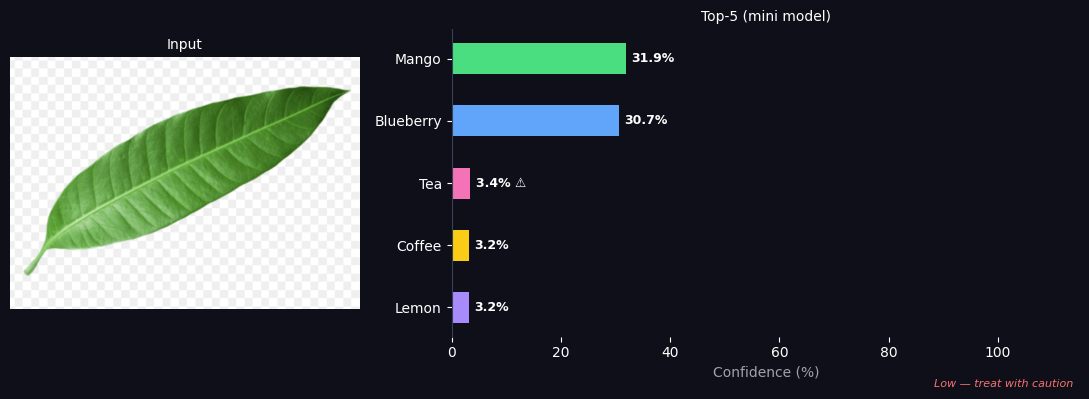


🌿  mango.png
    #   Crop                      Conf
    ───────────────────────────────────
    #1  Mango                    31.9%
    #2  Blueberry                30.7%
    #3  Tea                       3.4%  ⚠️ known weak class
    #4  Coffee                    3.2%
    #5  Lemon                     3.2%


In [ ]:
import json, torch, numpy as np, matplotlib.pyplot as plt, cv2
from pathlib import Path
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from google.colab import drive

drive.mount('/content/drive')

# Config
DRIVE_ROOT  = Path('/content/drive/MyDrive/CropClassifier_v2')
SAVE_MINI   = DRIVE_ROOT / 'models' / 'stage1_crop' / 'efficientnet_b1_crop_mini.pt'
NUM_CLASSES = 32
IMG_SIZE    = 240
NORM_MEAN   = (0.5, 0.5, 0.5)
NORM_STD    = (0.5, 0.5, 0.5)
TOP_K       = 5
IMAGE_PATH  = '/content/mango.png'

WEAK_CLASSES = {'tea', 'cotton'}

CROP_DISPLAY = {
    'apple': 'Apple', 'bean': 'Bean', 'bell_pepper': 'Bell Pepper',
    'blackgram': 'Blackgram', 'blueberry': 'Blueberry', 'cherry': 'Cherry',
    'chilli': 'Chilli', 'coconut': 'Coconut', 'coffee': 'Coffee',
    'corn': 'Corn / Maize', 'cotton': 'Cotton', 'dragon_fruit': 'Dragon Fruit',
    'grape': 'Grape', 'groundnut': 'Groundnut', 'jute': 'Jute',
    'lemon': 'Lemon', 'mango': 'Mango', 'onion': 'Onion', 'orange': 'Orange',
    'paddy': 'Paddy / Rice', 'peach': 'Peach', 'pineapple': 'Pineapple',
    'potato': 'Potato', 'raspberry': 'Raspberry', 'snake_gourd': 'Snake Gourd',
    'soybean': 'Soybean', 'squash': 'Squash', 'strawberry': 'Strawberry',
    'sugarcane': 'Sugarcane', 'tea': 'Tea', 'tomato': 'Tomato', 'wheat': 'Wheat',
}

# Load class map + model
with open(DRIVE_ROOT / 'models' / 'stage1_crop' / 'class_to_idx.json') as f:
    class_to_idx = json.load(f)
idx_to_class = {v: k for k, v in class_to_idx.items()}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

import timm
model = timm.create_model('efficientnet_b1', pretrained=False,
                           num_classes=NUM_CLASSES, drop_rate=0.0)
ckpt = torch.load(SAVE_MINI, map_location=device)
model.load_state_dict(ckpt['model_state'])
model = model.to(device).eval()
print(f'✅  Model loaded — epoch {ckpt["epoch"]} | val macro F1 = {ckpt["val_macro_f1"]:.4f}')
print(f'    ⚠️  This is the MINI model (70 samples/class). Expect lower accuracy than full training.')

# Transform
infer_transform = A.Compose([
    A.Resize(256, 256, interpolation=cv2.INTER_CUBIC),
    A.CenterCrop(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2(),
])

# Predict
def predict(image_path, top_k=TOP_K):
    img_pil = Image.open(image_path).convert('RGB')
    tensor  = infer_transform(image=np.array(img_pil))['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0].cpu()
    top_probs, top_idxs = probs.topk(top_k)
    return img_pil, [(idx_to_class[i.item()], p.item()) for i, p in zip(top_idxs, top_probs)]

def plot_prediction(img_pil, results, image_path):
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(11, 4),
                                          gridspec_kw={'width_ratios': [1, 1.8]})
    for ax in (ax_img, ax_bar): ax.set_facecolor('#0f0f1a')
    fig.patch.set_facecolor('#0f0f1a')

    ax_img.imshow(img_pil); ax_img.axis('off')
    ax_img.set_title('Input', color='white', fontsize=10)

    colors = ['#4ade80', '#60a5fa', '#f472b6', '#facc15', '#a78bfa']
    labels = [CROP_DISPLAY.get(c, c) for c, _ in results]
    values = [p * 100 for _, p in results]

    ax_bar.barh(labels[::-1], values[::-1],
                color=colors[:len(results)][::-1], height=0.5)
    for i, (v, (crop, _)) in enumerate(zip(values[::-1], results[::-1])):
        warn = ' ⚠️' if crop in WEAK_CLASSES else ''
        ax_bar.text(min(v + 1, 94), i, f'{v:.1f}%{warn}',
                    va='center', color='white', fontsize=9, fontweight='bold')

    ax_bar.set_xlim(0, 115)
    ax_bar.set_title(f'Top-{len(results)} (mini model)', color='white', fontsize=10)
    ax_bar.tick_params(colors='white')
    ax_bar.spines[['top', 'right', 'bottom']].set_visible(False)
    ax_bar.spines['left'].set_color('#374151')
    ax_bar.set_xlabel('Confidence (%)', color='#9ca3af')

    top_conf = values[0]
    conf_label = ('High confidence' if top_conf >= 90 else
                  'Moderate'        if top_conf >= 60 else 'Low — treat with caution')
    conf_color = '#4ade80' if top_conf >= 90 else '#facc15' if top_conf >= 60 else '#f87171'
    fig.text(0.98, 0.02, conf_label, ha='right', color=conf_color,
             fontsize=8, style='italic')
    plt.tight_layout(); plt.show()

    print(f'\n🌿  {Path(image_path).name}')
    print(f'    {"#":<3} {"Crop":<22} {"Conf":>7}')
    print(f'    {"─"*35}')
    for rank, (crop, prob) in enumerate(results, 1):
        warn = '  ⚠️ known weak class' if crop in WEAK_CLASSES else ''
        print(f'    #{rank:<2} {CROP_DISPLAY.get(crop, crop):<22} {prob*100:>6.1f}%{warn}')

# Run
img_pil, results = predict(IMAGE_PATH)
plot_prediction(img_pil, results, IMAGE_PATH)

# 08 : Two stage YOLO + EfficientNet

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅  EfficientNet loaded — epoch 7 | val macro F1 0.9791
✅  YOLO loaded: yolov8n.pt


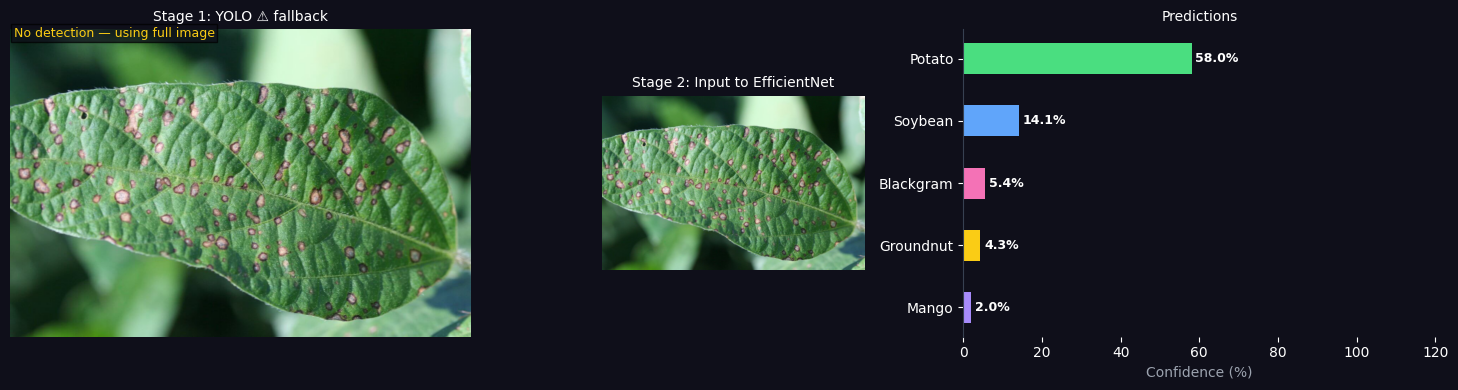


🌿  soybean.jpg
    Detection : ⚠️  No detection — full image fallback
    #    Crop                       Conf
    ──────────────────────────────────────
    #1   Potato                    58.0%
    #2   Soybean                   14.1%
    #3   Blackgram                  5.4%
    #4   Groundnut                  4.3%
    #5   Mango                      2.0%

    ℹ️  YOLO found no plant-class objects (conf > 0.25).
       Full image was used — accuracy depends on framing.
       Fix: replace YOLO_WEIGHTS with a leaf-specific model.


In [ ]:
!pip install -q ultralytics albumentations

import json, cv2, torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from ultralytics import YOLO
from google.colab import drive

drive.mount('/content/drive')



IMAGE_PATH   = '/content/soybean.jpg'



DRIVE_ROOT   = Path('/content/drive/MyDrive/CropClassifier_v2')
MODEL_PATH   = DRIVE_ROOT / 'models' / 'stage1_crop' / 'efficientnet_b1_crop_mini.pt'
CLASS_MAP    = DRIVE_ROOT / 'models' / 'stage1_crop' / 'class_to_idx.json'

# Swap this line when you have a leaf-specific model:
# YOLO_WEIGHTS = '/content/drive/MyDrive/CropClassifier_v2/models/yolo_leaf.pt'
YOLO_WEIGHTS = 'yolov8n.pt'   # downloads ~6MB on first run

# COCO class indices YOLO will accept as a "leaf / plant" hit.
# Extend this if your leaf-specific model uses different class ids.
PLANT_CLASSES    = {58}   # 58 = potted plant in COCO
CONF_THRESHOLD   = 0.25   # lower = more detections, more false positives
PAD_FRACTION     = 0.15   # padding added around detected box (fraction of box size)

NUM_CLASSES  = 32
IMG_SIZE     = 240
NORM_MEAN    = (0.5, 0.5, 0.5)
NORM_STD     = (0.5, 0.5, 0.5)
TOP_K        = 5
WEAK_CLASSES = {'tea', 'cotton'}

CROP_DISPLAY = {
    'apple': 'Apple', 'bean': 'Bean', 'bell_pepper': 'Bell Pepper',
    'blackgram': 'Blackgram', 'blueberry': 'Blueberry', 'cherry': 'Cherry',
    'chilli': 'Chilli', 'coconut': 'Coconut', 'coffee': 'Coffee',
    'corn': 'Corn / Maize', 'cotton': 'Cotton', 'dragon_fruit': 'Dragon Fruit',
    'grape': 'Grape', 'groundnut': 'Groundnut', 'jute': 'Jute',
    'lemon': 'Lemon', 'mango': 'Mango', 'onion': 'Onion', 'orange': 'Orange',
    'paddy': 'Paddy / Rice', 'peach': 'Peach', 'pineapple': 'Pineapple',
    'potato': 'Potato', 'raspberry': 'Raspberry', 'snake_gourd': 'Snake Gourd',
    'soybean': 'Soybean', 'squash': 'Squash', 'strawberry': 'Strawberry',
    'sugarcane': 'Sugarcane', 'tea': 'Tea', 'tomato': 'Tomato', 'wheat': 'Wheat',
}

# Load class map + EfficientNet
with open(CLASS_MAP) as f:
    class_to_idx = json.load(f)
idx_to_class = {v: k for k, v in class_to_idx.items()}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

import timm
effnet = timm.create_model('efficientnet_b1', pretrained=False,
                            num_classes=NUM_CLASSES, drop_rate=0.0)
ckpt = torch.load(MODEL_PATH, map_location=device)
effnet.load_state_dict(ckpt['model_state'])
effnet = effnet.to(device).eval()
print(f'✅  EfficientNet loaded — epoch {ckpt["epoch"]} | val macro F1 {ckpt["val_macro_f1"]:.4f}')


yolo = YOLO(YOLO_WEIGHTS)
print(f'✅  YOLO loaded: {YOLO_WEIGHTS}')

# Transform (same as train pipeline)
classify_transform = A.Compose([
    A.Resize(256, 256, interpolation=cv2.INTER_CUBIC),
    A.CenterCrop(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2(),
])

# Stage 1: YOLO detection
def detect_leaf(image_path, yolo_model, plant_classes, conf_thresh, pad_frac):
    """
    Returns (crop_pil, box_xyxy_or_None, detection_used: bool).
    box_xyxy is in original image pixel coordinates (before padding).
    If no detection fires, returns full image and detection_used=False.
    """
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise FileNotFoundError(f'Cannot open image: {image_path}')
    H, W = img_bgr.shape[:2]

    results = yolo_model(img_bgr, conf=conf_thresh, verbose=False)[0]

    # Filter to plant-class detections only
    boxes = []
    for box in results.boxes:
        cls_id = int(box.cls.item())
        conf   = float(box.conf.item())
        if cls_id in plant_classes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            boxes.append((conf, x1, y1, x2, y2))

    if not boxes:
        # Fallback: use full image
        img_pil = Image.open(image_path).convert('RGB')
        return img_pil, None, False

    # Use highest-confidence box
    boxes.sort(reverse=True)
    _, x1, y1, x2, y2 = boxes[0]

    # Add padding
    bw, bh = x2 - x1, y2 - y1
    pad_x, pad_y = bw * pad_frac, bh * pad_frac
    x1 = max(0,  int(x1 - pad_x))
    y1 = max(0,  int(y1 - pad_y))
    x2 = min(W,  int(x2 + pad_x))
    y2 = min(H,  int(y2 + pad_y))

    img_pil  = Image.open(image_path).convert('RGB')
    crop_pil = img_pil.crop((x1, y1, x2, y2))
    return crop_pil, (x1, y1, x2, y2), True

# Stage 2: EfficientNet classification
def classify_crop(crop_pil, model, transform, device, top_k):
    tensor = transform(image=np.array(crop_pil))['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0].cpu()
    top_probs, top_idxs = probs.topk(top_k)
    return [(idx_to_class[i.item()], p.item()) for i, p in zip(top_idxs, top_probs)]

# Visualise
def plot_two_stage(image_path, box, crop_pil, results, detection_used):
    img_full = np.array(Image.open(image_path).convert('RGB'))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4),
                              gridspec_kw={'width_ratios': [2, 1, 1.8]})
    for ax in axes: ax.set_facecolor('#0f0f1a')
    fig.patch.set_facecolor('#0f0f1a')

    # Panel 1 — full image + detected box
    axes[0].imshow(img_full)
    if detection_used and box:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor='#4ade80', facecolor='none')
        axes[0].add_patch(rect)
        axes[0].text(x1, y1 - 8, 'leaf detected', color='#4ade80', fontsize=9,
                     bbox=dict(facecolor='#0f0f1a', alpha=0.7, pad=2))
        stage1_label = 'Stage 1: YOLO ✅'
    else:
        axes[0].text(10, 20, 'No detection — using full image',
                     color='#facc15', fontsize=9,
                     bbox=dict(facecolor='#0f0f1a', alpha=0.7, pad=2))
        stage1_label = 'Stage 1: YOLO ⚠️ fallback'
    axes[0].set_title(stage1_label, color='white', fontsize=10)
    axes[0].axis('off')

    # Panel 2 — cropped region fed to classifier
    axes[1].imshow(crop_pil)
    axes[1].set_title('Stage 2: Input to EfficientNet', color='white', fontsize=10)
    axes[1].axis('off')

    # Panel 3 — bar chart
    colors = ['#4ade80', '#60a5fa', '#f472b6', '#facc15', '#a78bfa']
    labels = [CROP_DISPLAY.get(c, c) for c, _ in results]
    values = [p * 100 for _, p in results]
    axes[2].barh(labels[::-1], values[::-1],
                  color=colors[:len(results)][::-1], height=0.5)
    for i, (v, (crop, _)) in enumerate(zip(values[::-1], results[::-1])):
        warn = ' ⚠️' if crop in WEAK_CLASSES else ''
        axes[2].text(min(v+1, 92), i, f'{v:.1f}%{warn}',
                     va='center', color='white', fontsize=9, fontweight='bold')
    axes[2].set_xlim(0, 120)
    axes[2].set_title('Predictions', color='white', fontsize=10)
    axes[2].tick_params(colors='white')
    axes[2].spines[['top', 'right', 'bottom']].set_visible(False)
    axes[2].spines['left'].set_color('#374151')
    axes[2].set_xlabel('Confidence (%)', color='#9ca3af')

    plt.tight_layout()
    plt.savefig('/content/two_stage_result.png', dpi=130, bbox_inches='tight')
    plt.show()

    # Text summary
    print(f'\n🌿  {Path(image_path).name}')
    print(f'    Detection : {"YOLO box used" if detection_used else "⚠️  No detection — full image fallback"}')
    print(f'    {"#":<3}  {"Crop":<22}  {"Conf":>7}')
    print(f'    {"─"*38}')
    for rank, (crop, prob) in enumerate(results, 1):
        warn = '  ⚠️ weak class' if crop in WEAK_CLASSES else ''
        print(f'    #{rank:<2}  {CROP_DISPLAY.get(crop,crop):<22}  {prob*100:>6.1f}%{warn}')

    if not detection_used:
        print(f'\n    ℹ️  YOLO found no plant-class objects (conf > {CONF_THRESHOLD}).')
        print(f'       Full image was used — accuracy depends on framing.')
        print(f'       Fix: replace YOLO_WEIGHTS with a leaf-specific model.')

# run
crop_pil, box, detection_used = detect_leaf(
    IMAGE_PATH, yolo, PLANT_CLASSES, CONF_THRESHOLD, PAD_FRACTION
)
results = classify_crop(crop_pil, effnet, classify_transform, device, TOP_K)
plot_two_stage(IMAGE_PATH, box, crop_pil, results, detection_used)

---

---

# CELL Y0 │ Build YOLO classify folder structure from mini manifests
### Safe to re-run: wipes and rebuilds YOLO_DIR cleanly each time.

In [ ]:
import shutil
import pandas as pd
from pathlib import Path

DATA_ROOT = Path('/content/dataset/resized_256')
MINI_DIR  = Path('/content/mini')
YOLO_DIR  = Path('/content/yolo_dataset')

# Wipe and rebuild cleanly
if YOLO_DIR.exists():
    shutil.rmtree(YOLO_DIR)
YOLO_DIR.mkdir(parents=True)

def build_split(csv_path, split_name):
    df = pd.read_csv(csv_path)
    copied, failed = 0, 0
    for _, row in df.iterrows():
        src = DATA_ROOT / row['filepath']
        dst = YOLO_DIR / split_name / row['crop'] / src.name
        dst.parent.mkdir(parents=True, exist_ok=True)
        if src.exists():
            shutil.copy2(src, dst)
            copied += 1
        else:
            failed += 1
    return copied, failed

for split, csv in [('train', MINI_DIR/'train_mini.csv'),
                   ('val',   MINI_DIR/'val_mini.csv'),
                   ('test',  MINI_DIR/'test_mini.csv')]:
    copied, failed = build_split(csv, split)
    print(f'  {split:<6} copied: {copied:,}  failed: {failed:,}')

# Verify structure
print(f'\nYOLO dataset structure:')
for split in ['train', 'val', 'test']:
    classes = list((YOLO_DIR/split).iterdir())
    total   = sum(len(list(c.iterdir())) for c in classes)
    print(f'  {split:<6} {len(classes)} classes  {total:,} images')

print(f'\n✅  YOLO dataset ready at {YOLO_DIR}')

  train  copied: 2,240  failed: 0
  val    copied: 480  failed: 0
  test   copied: 480  failed: 0

YOLO dataset structure:
  train  32 classes  2,240 images
  val    32 classes  480 images
  test   32 classes  480 images

✅  YOLO dataset ready at /content/yolo_dataset


# CELL Y1 │ Train YOLOv11 classify


In [ ]:
!pip install -q ultralytics

from ultralytics import YOLO
from pathlib import Path

DRIVE_ROOT  = Path('/content/drive/MyDrive/CropClassifier_v2')
YOLO_SAVE   = DRIVE_ROOT / 'models' / 'stage1_crop'
YOLO_SAVE.mkdir(parents=True, exist_ok=True)

# yolo11n-cls = nano classify — fastest, smallest
# options: yolo11n-cls, yolo11s-cls, yolo11m-cls
# nano is fine for a test/comparison run
model = YOLO('yolo11n-cls.pt')

results = model.train(
    data    = str(Path('/content/yolo_dataset')),
    epochs  = 8,
    imgsz   = 240,
    batch   = 64,
    workers = 4,
    device  = 0 if __import__('torch').cuda.is_available() else 'cpu',

    # Optimizer
    optimizer = 'AdamW',
    lr0       = 1e-3,
    lrf       = 1e-2,      # final lr = lr0 * lrf
    weight_decay = 1e-4,

    # Augmentation — keep comparable to EfficientNet mini
    hsv_h  = 0.015,
    hsv_s  = 0.4,
    hsv_v  = 0.4,
    fliplr = 0.5,
    flipud = 0.3,
    degrees= 20.0,

    # Output
    project = str(YOLO_SAVE),
    name    = 'yolo11n_crop_mini',
    exist_ok= True,
    verbose = True,
)

print(f'\n✅  Training complete')
print(f'    Results saved → {YOLO_SAVE}/yolo11n_crop_mini/')

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset, degrees=20.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=8, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=240, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_crop_mini, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, pa

# CELL Y2 │ Evaluate YOLOv11 on test set + print comparison table

In [ ]:
import torch
import numpy as np
from pathlib import Path
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from ultralytics import YOLO
from tqdm.auto import tqdm
from PIL import Image

YOLO_SAVE  = Path('/content/drive/MyDrive/CropClassifier_v2/models/stage1_crop')
YOLO_DIR   = Path('/content/yolo_dataset')
best_pt    = YOLO_SAVE / 'yolo11n_crop_mini' / 'weights' / 'best.pt'

model = YOLO(best_pt)
print(f'✅  Loaded: {best_pt}')

# Get class order YOLO used during training
# (YOLO sorts classes alphabetically — must match our label encoding)
yolo_classes = model.names   # dict {0: 'apple', 1: 'bean', ...}
print(f'    Classes: {len(yolo_classes)}')

# Run inference on test set
all_preds, all_labels = [], []
test_dir = YOLO_DIR / 'test'

for class_dir in sorted(test_dir.iterdir()):
    true_label = list(yolo_classes.values()).index(class_dir.name) \
                 if class_dir.name in yolo_classes.values() else -1
    if true_label == -1:
        print(f'  ⚠️  {class_dir.name} not in YOLO classes — skipping')
        continue
    for img_path in class_dir.iterdir():
        result = model(str(img_path), verbose=False)[0]
        pred   = result.probs.top1
        all_preds.append(pred)
        all_labels.append(true_label)

acc      = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
w_f1     = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f'\n{"="*55}')
print(f'  YOLO v11 nano — TEST RESULTS (mini, 70 samples/class)')
print(f'{"="*55}')
print(f'  Accuracy    : {acc:.4f}')
print(f'  Macro F1    : {macro_f1:.4f}')
print(f'  Weighted F1 : {w_f1:.4f}')
print(f'{"="*55}')

# Per-class F1
crop_f1s = f1_score(all_labels, all_preds, average=None, zero_division=0)
print(f'\nPer-class F1 (worst → best):')
for i, f1 in sorted(enumerate(crop_f1s), key=lambda x: x[1]):
    bar  = '█' * int(f1 * 20)
    flag = '  ⚠️' if f1 < 0.5 else ''
    print(f'  {yolo_classes[i]:<18} {f1:.3f}  {bar}{flag}')


EFFNET_ACC   = 0.9750
EFFNET_MF1   = 0.9751

print(f'\n{"="*55}')
print(f'  Head-to-head comparison (mini, 70 samples/class, 8 epochs)')
print(f'{"="*55}')
print(f'  {"Model":<22} {"Accuracy":>9}  {"Macro F1":>9}')
print(f'  {"─"*44}')
print(f'  {"YOLOv11n-cls":<22} {acc:>9.4f}  {macro_f1:>9.4f}')
if EFFNET_ACC and EFFNET_MF1:
    print(f'  {"EfficientNet-B1":<22} {EFFNET_ACC:>9.4f}  {EFFNET_MF1:>9.4f}')
    winner_acc = "YOLO" if acc > EFFNET_ACC else "EfficientNet"
    winner_f1  = "YOLO" if macro_f1 > EFFNET_MF1 else "EfficientNet"
    print(f'\n  Accuracy winner : {winner_acc}')
    print(f'  Macro F1 winner : {winner_f1}')
else:
    print(f'  {"EfficientNet-B1":<22} {"run mini nb":>9}  {"to fill in":>9}')
print(f'{"="*55}')

✅  Loaded: /content/drive/MyDrive/CropClassifier_v2/models/stage1_crop/yolo11n_crop_mini/weights/best.pt
    Classes: 32

  YOLO v11 nano — TEST RESULTS (mini, 70 samples/class)
  Accuracy    : 0.9771
  Macro F1    : 0.9775
  Weighted F1 : 0.9775

Per-class F1 (worst → best):
  coconut            0.882  █████████████████
  pineapple          0.929  ██████████████████
  blackgram          0.933  ██████████████████
  strawberry         0.938  ██████████████████
  tomato             0.938  ██████████████████
  bell_pepper        0.966  ███████████████████
  blueberry          0.966  ███████████████████
  grape              0.966  ███████████████████
  groundnut          0.966  ███████████████████
  onion              0.966  ███████████████████
  potato             0.966  ███████████████████
  raspberry          0.966  ███████████████████
  sugarcane          0.966  ███████████████████
  bean               0.968  ███████████████████
  cotton             0.968  ███████████████████
  apple  


# CELL Y3 │ YOLOv11 standalone inference  (no prior cells needed)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅  Loaded YOLOv11n-cls  |  32 classes


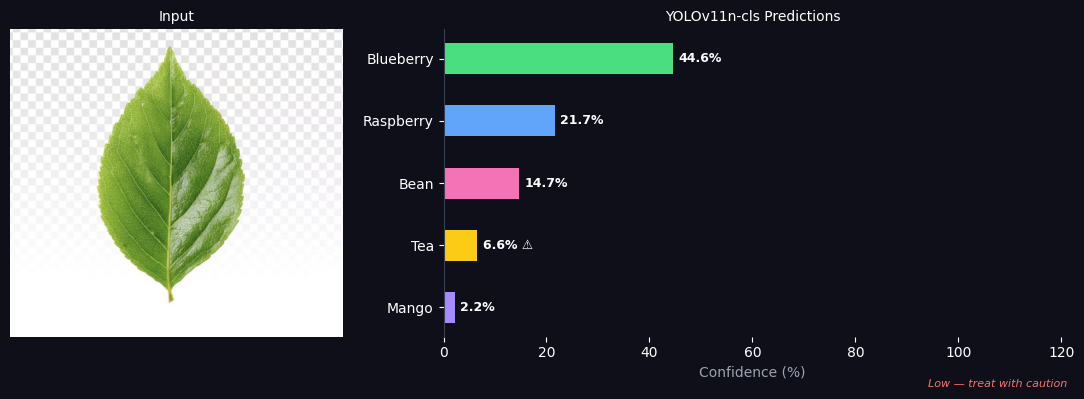


🌿  tea3.png  (YOLOv11n-cls)
    #    Crop                       Conf
    ──────────────────────────────────────
    #1   Blueberry                 44.6%
    #2   Raspberry                 21.7%
    #3   Bean                      14.7%
    #4   Tea                        6.6%  ⚠️ weak class
    #5   Mango                      2.2%


In [ ]:
!pip install -q ultralytics

from ultralytics import YOLO
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

IMAGE_PATH = '/content/tea3.png'
YOLO_SAVE  = Path('/content/drive/MyDrive/CropClassifier_v2/models/stage1_crop')
best_pt    = YOLO_SAVE / 'yolo11n_crop_mini' / 'weights' / 'best.pt'
TOP_K      = 5
WEAK_CLASSES = {'tea', 'cotton'}

CROP_DISPLAY = {
    'apple': 'Apple', 'bean': 'Bean', 'bell_pepper': 'Bell Pepper',
    'blackgram': 'Blackgram', 'blueberry': 'Blueberry', 'cherry': 'Cherry',
    'chilli': 'Chilli', 'coconut': 'Coconut', 'coffee': 'Coffee',
    'corn': 'Corn / Maize', 'cotton': 'Cotton', 'dragon_fruit': 'Dragon Fruit',
    'grape': 'Grape', 'groundnut': 'Groundnut', 'jute': 'Jute',
    'lemon': 'Lemon', 'mango': 'Mango', 'onion': 'Onion', 'orange': 'Orange',
    'paddy': 'Paddy / Rice', 'peach': 'Peach', 'pineapple': 'Pineapple',
    'potato': 'Potato', 'raspberry': 'Raspberry', 'snake_gourd': 'Snake Gourd',
    'soybean': 'Soybean', 'squash': 'Squash', 'strawberry': 'Strawberry',
    'sugarcane': 'Sugarcane', 'tea': 'Tea', 'tomato': 'Tomato', 'wheat': 'Wheat',
}

model = YOLO(best_pt)
yolo_classes = model.names
print(f'✅  Loaded YOLOv11n-cls  |  {len(yolo_classes)} classes')

def predict(image_path, top_k=TOP_K):
    result = model(str(image_path), verbose=False)[0]
    probs  = result.probs
    top_indices = probs.top5[:top_k]
    top_confs   = probs.top5conf[:top_k].tolist()
    return [(yolo_classes[i], c) for i, c in zip(top_indices, top_confs)]

def plot_prediction(image_path, results):
    img_pil = Image.open(image_path).convert('RGB')
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(11, 4),
                                          gridspec_kw={'width_ratios': [1, 1.8]})
    for ax in (ax_img, ax_bar): ax.set_facecolor('#0f0f1a')
    fig.patch.set_facecolor('#0f0f1a')

    ax_img.imshow(img_pil); ax_img.axis('off')
    ax_img.set_title('Input', color='white', fontsize=10)

    colors = ['#4ade80', '#60a5fa', '#f472b6', '#facc15', '#a78bfa']
    labels = [CROP_DISPLAY.get(c, c) for c, _ in results]
    values = [p * 100 for _, p in results]

    ax_bar.barh(labels[::-1], values[::-1],
                color=colors[:len(results)][::-1], height=0.5)
    for i, (v, (crop, _)) in enumerate(zip(values[::-1], results[::-1])):
        warn = ' ⚠️' if crop in WEAK_CLASSES else ''
        ax_bar.text(min(v+1, 92), i, f'{v:.1f}%{warn}',
                    va='center', color='white', fontsize=9, fontweight='bold')

    ax_bar.set_xlim(0, 120)
    ax_bar.set_title('YOLOv11n-cls Predictions', color='white', fontsize=10)
    ax_bar.tick_params(colors='white')
    ax_bar.spines[['top','right','bottom']].set_visible(False)
    ax_bar.spines['left'].set_color('#374151')
    ax_bar.set_xlabel('Confidence (%)', color='#9ca3af')

    top_conf   = values[0]
    conf_label = ('High confidence' if top_conf >= 90 else
                  'Moderate'        if top_conf >= 60 else 'Low — treat with caution')
    conf_color = '#4ade80' if top_conf >= 90 else '#facc15' if top_conf >= 60 else '#f87171'
    fig.text(0.98, 0.02, conf_label, ha='right',
             color=conf_color, fontsize=8, style='italic')

    plt.tight_layout(); plt.show()

    print(f'\n🌿  {Path(image_path).name}  (YOLOv11n-cls)')
    print(f'    {"#":<3}  {"Crop":<22}  {"Conf":>7}')
    print(f'    {"─"*38}')
    for rank, (crop, prob) in enumerate(results, 1):
        warn = '  ⚠️ weak class' if crop in WEAK_CLASSES else ''
        print(f'    #{rank:<2}  {CROP_DISPLAY.get(crop,crop):<22}  {prob*100:>6.1f}%{warn}')

results = predict(IMAGE_PATH)
plot_prediction(IMAGE_PATH, results)

In [ ]:
!unzip -q -o "/content/drive/MyDrive/disease_detection/Diseased and healthy leaf images of crops.zip" -d "/content/drive/MyDrive/disease_detection/unseen" -x "__MACOSX/*" "*/._*"


caution: excluded filename not matched:  */._*


In [ ]:
from pathlib import Path

UNSEEN_DIR = Path('/content/drive/MyDrive/disease_detection/unseen/Diseased_and_healthy')

print('Folder structure:\n')
for folder in sorted(UNSEEN_DIR.iterdir()):
    if folder.is_dir():
        imgs = list(folder.rglob('*'))
        imgs = [f for f in imgs if f.suffix.lower() in {'.jpg','.jpeg','.png','.bmp','.webp'}]
        print(f'  {folder.name:<40} {len(imgs):>4} images')

Folder structure:

  Beans                                       7 images
  Bell peper                                 11 images
  Blackgram                                   9 images
  Blueberry                                  12 images
  Cherry                                      9 images
  Chilli                                     12 images
  Coconut                                    10 images
  Coffee                                      9 images
  Corn                                       14 images
  Cotton                                     12 images
  Dragonfruit                                10 images
  Grape                                      12 images
  Groundnut                                  11 images
  Jute                                        9 images
  Lemon                                      12 images
  Mango                                      14 images
  apple                                      10 images
  onion                                       

# CELL OOD (out-of-distribution) │ Unseen data evaluation — both models


In [ ]:

# CELL OOD (out-of-distribution) │ Unseen data evaluation — both models
!pip install -q ultralytics

import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A
import cv2
from albumentations.pytorch import ToTensorV2
from pathlib import Path
from PIL import Image
from ultralytics import YOLO
import timm
from google.colab import drive

drive.mount('/content/drive')

UNSEEN_DIR  = Path('/content/drive/MyDrive/disease_detection/unseen/Diseased_and_healthy')
DRIVE_ROOT  = Path('/content/drive/MyDrive/CropClassifier_v2')
MODEL_DIR   = DRIVE_ROOT / 'models' / 'stage1_crop'

IMG_EXTS    = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
IMG_SIZE    = 240
NORM_MEAN   = (0.5, 0.5, 0.5)
NORM_STD    = (0.5, 0.5, 0.5)
NUM_CLASSES = 32


FOLDER_TO_CLASS = {
    'apple'       : 'apple',
    'beans'       : 'bean',
    'bell pepper' : 'bell_pepper',
    'blackgram'   : 'blackgram',
    'blueberry'   : 'blueberry',
    'cherry'      : 'cherry',
    'chilli'      : 'chilli',
    'coconut'     : 'coconut',
    'coffee'      : 'coffee',
    'corn'        : 'corn',
    'cotton'      : 'cotton',
    'dragonfruit' : 'dragon_fruit',
    'grape'       : 'grape',
    'groundnut'   : 'groundnut',
    'jute'        : 'jute',
    'lemon'       : 'lemon',
    'mango'       : 'mango',
    'onion'       : 'onion',
    'orange'      : 'orange',
    'paddy'       : 'paddy',
    'peach'       : 'peach',
    'pineapple'   : 'pineapple',
    'potato'      : 'potato',
    'raspberry'   : 'raspberry',
    'snake gourd' : 'snake_gourd',
    'soybean'     : 'soybean',
    'squash'      : 'squash',
    'strawberry'  : 'strawberry',
    'sugarcane'   : 'sugarcane',
    'tea'         : 'tea',
    'tomato'      : 'tomato',
    'wheat'       : 'wheat',
}

# Load class map
with open(MODEL_DIR / 'class_to_idx.json') as f:
    class_to_idx = json.load(f)
idx_to_class = {v: k for k, v in class_to_idx.items()}

# Load EfficientNet
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

effnet = timm.create_model('efficientnet_b1', pretrained=False,
                            num_classes=NUM_CLASSES, drop_rate=0.0)
ckpt = torch.load(MODEL_DIR / 'efficientnet_b1_crop_mini.pt', map_location=device)
effnet.load_state_dict(ckpt['model_state'])
effnet = effnet.to(device).eval()

effnet_transform = A.Compose([
    A.Resize(256, 256, interpolation=cv2.INTER_CUBIC),
    A.CenterCrop(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2(),
])

# Load YOLO
yolo = YOLO(MODEL_DIR / 'yolo11n_crop_mini' / 'weights' / 'best.pt')
yolo_classes = yolo.names  # {0: 'apple', ...}
yolo_name_to_idx = {v: k for k, v in yolo_classes.items()}

# Inference functions
def predict_effnet(img_path):
    img = np.array(Image.open(img_path).convert('RGB'))
    tensor = effnet_transform(image=img)['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(effnet(tensor), dim=1)[0].cpu()
    pred_idx = probs.argmax().item()
    return idx_to_class[pred_idx], probs[pred_idx].item()

def predict_yolo(img_path):
    result = yolo(str(img_path), verbose=False)[0]
    pred_idx = result.probs.top1
    return yolo_classes[pred_idx], result.probs.top1conf.item()

# Run inference on all unseen images
records = []
unmapped = []

for folder in sorted(UNSEEN_DIR.iterdir()):
    if not folder.is_dir():
        continue

    folder_key = folder.name.lower().strip()
    if folder_key not in FOLDER_TO_CLASS:
        unmapped.append(folder.name)
        continue

    true_class = FOLDER_TO_CLASS[folder_key]
    imgs = [f for f in folder.iterdir() if f.suffix.lower() in IMG_EXTS]

    for img_path in imgs:
        eff_pred, eff_conf   = predict_effnet(img_path)
        yolo_pred, yolo_conf = predict_yolo(img_path)
        records.append({
            'true'        : true_class,
            'folder'      : folder.name,
            'image'       : img_path.name,
            'eff_pred'    : eff_pred,
            'eff_conf'    : eff_conf,
            'eff_correct' : eff_pred == true_class,
            'yolo_pred'   : yolo_pred,
            'yolo_conf'   : yolo_conf,
            'yolo_correct': yolo_pred == true_class,
        })

if unmapped:
    print(f'⚠️  Unmapped folders (fix FOLDER_TO_CLASS): {unmapped}')

df = pd.DataFrame(records)
print(f'✅  Ran inference on {len(df)} images across {df["true"].nunique()} crops')

# Per-crop results
summary = df.groupby('true').agg(
    n_images      = ('image',        'count'),
    eff_correct   = ('eff_correct',  'sum'),
    yolo_correct  = ('yolo_correct', 'sum'),
    eff_conf_mean = ('eff_conf',     'mean'),
    yolo_conf_mean= ('yolo_conf',    'mean'),
).reset_index()

summary['eff_acc']  = summary['eff_correct']  / summary['n_images']
summary['yolo_acc'] = summary['yolo_correct'] / summary['n_images']
summary = summary.sort_values('yolo_acc', ascending=True)

# Print table
print(f'\n{"─"*80}')
print(f'  {"Crop":<18} {"N":>4}  {"EffNet Acc":>10}  {"EffNet Conf":>11}  {"YOLO Acc":>9}  {"YOLO Conf":>10}')
print(f'{"─"*80}')

for _, row in summary.iterrows():
    eff_flag  = '⚠️ ' if row['eff_acc']  < 0.7 else '✅ '
    yolo_flag = '⚠️ ' if row['yolo_acc'] < 0.7 else '✅ '
    print(f'  {row["true"]:<18} {row["n_images"]:>4}  '
          f'{eff_flag}{row["eff_acc"]:>6.1%}  {row["eff_conf_mean"]:>11.1%}  '
          f'{yolo_flag}{row["yolo_acc"]:>6.1%}  {row["yolo_conf_mean"]:>10.1%}')

print(f'{"─"*80}')
overall_eff  = df['eff_correct'].mean()
overall_yolo = df['yolo_correct'].mean()
print(f'  {"OVERALL":<18} {len(df):>4}  '
      f'   {overall_eff:>6.1%}{"":>12}'
      f'   {overall_yolo:>6.1%}')
print(f'{"─"*80}')

# Both models wrong on same image
both_wrong = df[~df['eff_correct'] & ~df['yolo_correct']]
if len(both_wrong):
    print(f'\n⚠️  Both models wrong on {len(both_wrong)} images:')
    for _, row in both_wrong.iterrows():
        print(f'  {row["folder"]}/{row["image"]}')
        print(f'    EffNet → {row["eff_pred"]} ({row["eff_conf"]:.1%})')
        print(f'    YOLO   → {row["yolo_pred"]} ({row["yolo_conf"]:.1%})')

# Save results to Drive
df.to_csv(DRIVE_ROOT / 'ood_results.csv', index=False)
summary.to_csv(DRIVE_ROOT / 'ood_summary.csv', index=False)
print(f'\n✅  Results saved to Drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⚠️  Unmapped folders (fix FOLDER_TO_CLASS): ['bean', 'bell_pepper', 'dragon_fruit', 'snake_gourd']
✅  Ran inference on 307 images across 28 crops

────────────────────────────────────────────────────────────────────────────────
  Crop                  N  EffNet Acc  EffNet Conf   YOLO Acc   YOLO Conf
───────────────────────

In [ ]:
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

DATA_ROOT = Path('/content/dataset/resized_256')
IMG_EXTS  = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

for crop_folder in sorted(DATA_ROOT.iterdir()):
    if not crop_folder.is_dir():
        continue
    subfolders = [p for p in crop_folder.iterdir() if p.is_dir()]
    if not subfolders:
        continue
    print(f'\n{crop_folder.name}:')
    for sub in sorted(subfolders):
        n = sum(1 for f in sub.rglob('*') if f.suffix.lower() in IMG_EXTS)
        print(f'  {sub.name:<55} {n:>5}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

An_India_soyabean_leaf_dataset:
  Bacterial_leaf_Blight                                     226
  Dry_leaf                                                  230
  Healthy                                                   288
  Septoria_Brown_Spot                                       284
  Vein_Necrosis                                             138

Apple:
  Apple_scab                                               2520
  Black_rot                                                2484
  Cedar_apple_rust                                         2200
  healthy                                                  2510

Bean Health and Disease Dataset A Resource for Agr:
  Angular-Leaf-Spot                                         270
  Bacterial Pathogen                                        418
  Cercospora-Leaf-Spot                                      160
  Fungi-P

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q ultralytics

from pathlib import Path
from ultralytics import YOLO

YOLO_SAVE = Path('/content/drive/MyDrive/CropClassifier_v2/models/stage1_crop')
best_pt   = YOLO_SAVE / 'yolo11n_crop_mini' / 'weights' / 'best.pt'

yolo = YOLO(best_pt)

# .model gives the underlying nn.Module
total_params     = sum(p.numel() for p in yolo.model.parameters())
trainable_params = sum(p.numel() for p in yolo.model.parameters() if p.requires_grad)

print(f'YOLOv11n-cls')
print(f'  Total params     : {total_params/1e6:.2f}M')
print(f'  Trainable params : {trainable_params/1e6:.2f}M')

YOLOv11n-cls
  Total params     : 1.57M
  Trainable params : 0.00M


In [ ]:
# Param count check — EfficientNet-B0 (Stage 2)
import timm

effnet_b0 = timm.create_model('efficientnet_b0', pretrained=False, num_classes=NUM_CLASSES)
total_b0     = sum(p.numel() for p in effnet_b0.parameters())
trainable_b0 = sum(p.numel() for p in effnet_b0.parameters() if p.requires_grad)

print(f'\nEfficientNet-B0')
print(f'  Total params     : {total_b0/1e6:.2f}M')
print(f'  Trainable params : {trainable_b0/1e6:.2f}M')

NameError: name 'NUM_CLASSES' is not defined